# STRATA — Marco práctico: ¿aporta valor supervisar estadísticamente a un agente LLM de trading?

**Notebook DEFINITIVO y canónico del TFG** (Raquel García, Matemáticas y Ciencia de Datos, UCM). Rama
`feat/quant-validation-panel`. Sustituye y consolida los cuadernos previos (`STRATA_SMCI`, `decision_automl`).

**Tesis del capítulo.** Un agente LLM de trading (AI Hedge Fund, 5 personalidades) puede perder dinero y
acertar la dirección menos del 50%. La pregunta del TFG no es *"¿la IA acierta?"* sino *"¿una capa de
supervisión estadística clásica (STRATA: régimen, cambio de opinión, volatilidad) **rescata** a ese agente, y
puede **probarse** ese rescate?"*. Este cuaderno lo defiende como lo haría un quant ante un comité: vende con
el caso **SPY**, pero **prueba** con lo que sobrevive a un test.

**Las tres patas del valor diferencial (lo que sí se contrasta):**
1. **Rescate del agente** — los modelos supervisados baten al agente solo (M5) en accuracy de forma
   **significativa** (McNemar pareado) y reducen su riesgo.
2. **Universalidad** — un ML potente (XGBoost / AutoML-H2O) **redescubre** las señales de STRATA (SHAP), no
   inventa otra; la cuota de importancia STRATA es alta.
3. **Patrón** — agrupando los activos por su naturaleza emerge qué estrategia conviene a cada grupo.

**Honestidad (la lleva el cuaderno, no la esconde):** batir al *baseline trivial* ZeroR (apostar la clase
mayoritaria) o a B&H **en accuracy** es **nominal, no significativo** (n≈250 → ventana corta, línea futura).
STRATA **no genera alfa**: rescata al perdedor y delimita dónde funciona.

Estrategias: **M5** agente · **M8** STRATA (regla, override-C) · **M10** meta-learner XGBoost (canónico) ·
**AutoML** (búsqueda H2O) · **ZeroR** clase mayoritaria · **B&H** comprar-y-mantener · **Régimen** (canal HMM).

## Objetivos del marco práctico

| | Objetivo | Cómo se valida |
|---|---|---|
| **O1** | El agente solo (M5) pierde y acierta < 0.5 | sign test vs 0.5; Sharpe causal negativo |
| **O2** | STRATA **rescata** al agente | accuracy: McNemar M8/M10/AutoML vs M5; riesgo: ΔSharpe/ΔmaxDD bootstrap IC95 (pooled) |
| **O3** | Un ML potente **redescubre** STRATA (universalidad) | SHAP por bloque (cuota STRATA) + permutation; ablación |
| **O4** | Existe un **patrón** activo→estrategia | clustering multi-algoritmo + concordancia (Rand) |
| **O5** | **Honestidad**: no se bate al baseline/mercado de forma significativa; límite de alcance | McNemar vs ZeroR (nominal); decisión #16 (leverage débil) |
| **O6** | **Rigor**: cada cifra con test + IC + cita; `signal_lag=1`; sin KFold; pre-registro | barrera temporal; auto-test; BITÁCORA |

## Notación

| Símbolo | Significado |
|---|---|
| $r_t$ | log-retorno del día $t$ |
| $r_{t+1}$ | retorno del día siguiente (lo que la posición de hoy captura) |
| $y_t = \mathbb{1}[r_{t+1}>0]$ | etiqueta direccional (horizonte 1) |
| $s_t \in \{$Calma, Estrés, Crisis$\}$ | régimen oculto (HMM K=3) |
| $\gamma_{t,k}=P(s_t=k\mid \mathcal{F}_t)$ | posterior filtrado del régimen (causal) |
| $\sigma_t$ | volatilidad condicional GARCH(1,1)-t (prevista antes de ver $r_t$) |
| $w_t \in \{-1,0,+1\}$ | posición supervisada (signo); P&L con `signal_lag=1`: $w_t \cdot r_{t+1}$ |
| $p_{1,t}=P(y_t=1)$ | probabilidad del meta-learner (M10/AutoML), umbral 0.5 |

**Disciplina causal (innegociable):** la posición de $t$ multiplica al retorno de $t+1$ (`signal_lag=1`).
Nunca $w_t\cdot r_t$.

In [1]:
# --- Bootstrap raíz + carga de TODOS los JSON auditados ---
import os, sys, json, warnings
from pathlib import Path
_ROOT = Path.cwd()
while not (_ROOT / "config.py").exists() and _ROOT != _ROOT.parent:
    _ROOT = _ROOT.parent
os.chdir(_ROOT); sys.path.insert(0, str(_ROOT)); warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def _load(p): return json.load(open(p))
DP  = _load("outputs/experiments/decision_automl_prep.json")
PAN = _load("outputs/experiments/automl_runs/"
            "panel_mm25_inclGBM-XGB-SE_AUC_emb1_N0-150_step21_kfold_seed42.json")["por_activo"]
IMP = _load("outputs/experiments/automl_importance.json")["por_activo"]
CLU = _load("outputs/experiments/strategy_clustering15.json")
SPYR = _load("outputs/experiments/spy_m10_full_report.json")          # SPY: métricas M10 + tests
SPYA = _load("outputs/experiments/spy_ablation_robustness.json")      # SPY: ablación STRATA vs momentum (bloques)
SMV = _load("outputs/experiments/m10_smci_valtest_robustez.json")     # SMCI: principal + splits
SME = _load("outputs/experiments/m10_smci_embargo.json")             # SMCI: embargo
SMR = _load("outputs/experiments/m10_smci_rolling.json")            # SMCI: ventanas rodantes
SMC = _load("outputs/experiments/smci_calib_window.json")           # SMCI: ventana de calibración
RDT = _load("outputs/experiments/regime_direction_table.json")       # SPY: dirección por régimen (calib/oos)

DPA = DP["por_activo"]
ASSETS = [a for a in DP["meta"]["panel"] if a in DPA and "error" not in DPA[a]]
COL = {"M5": "#9e9e9e", "M8": "#f0a830", "M10": "#2c7fb8", "AutoML": "#27ae60",
       "ZeroR": "#7d3c98", "B&H": "#c0392b"}
REGCOL = {0: "#2e9e4f", 1: "#e8a33d", 2: "#c0392b"}; REGNAME = {0: "Calma", 1: "Estrés", 2: "Crisis"}
PKEY = {"M5": "m5", "M8": "m8", "M10": "m10_xgb", "AutoML": "automl", "ZeroR": "zeror", "B&H": "bh"}  # panel
DKEY = {"M5": "m5", "M8": "m8", "M10": "m10", "ZeroR": "zeror", "B&H": "bh"}                          # prep
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
print("activos:", len(ASSETS), "·", ", ".join(ASSETS))
print("ventana (M10 desplegable):", DP["meta"]["ventana"])
print("M10 canónico:", DP["meta"]["m10"])

activos: 15 · SPY, QQQ, DIA, IWM, XLE, XLF, XLK, NVDA, BAC, TSLA, MSTR, SMCI, ROKU, MARA, UNG
ventana (M10 desplegable): walk-forward M10 (~250 d tras burn-in 150)
M10 canónico: canónico: ensemble 10 XGBoost, embargo=1, N0=150, ALL22 (quant_validation_panel.wf_p1)


## §4.1 Datos, universo y protocolo

- **Universo.** Caso central **SPY** (S&P 500). Panel de robustez: 15 activos (índices, sectoriales, acciones,
  cripto-proxy, commodity). Justificación del caso central: el **leverage effect** (Black 1976; Christie 1982)
  es una relación **contemporánea** (mismo día) entre retorno y volatilidad — en índices como SPY las caídas
  coinciden con subidas de volatilidad. El HMM separa el OOS por **volatilidad**; bajo leverage fuerte ese eje
  está correlacionado (mismo día) con el signo del retorno, lo que da a la supervisión algo de "dónde
  agarrarse". Es un proxy direccional **débil y condicional al activo**, no una predicción del día siguiente —
  limitación documentada (§4.6).
- **Calibración.** 2000-01-01 → 2024-09-30 (24 años). HMM / GARCH / BOCPD se entrenan **una sola vez**; sus
  umbrales se fijan **ex-ante**, nunca sobre el OOS.
- **OOS.** 2024-10-01 → cierre del TFG. Inicio posterior al cutoff de DeepSeek V3 para eliminar look-ahead del
  LLM. El M10/AutoML desplegable evalúa la ventana tras el burn-in (≈250 días).
- **Protocolo.** Walk-forward expandible: burn-in $N_0=150$, reentreno cada 21 días, **embargo=1** (horizonte de
  etiqueta = 1; rolling-origin — Tashman 2000; López de Prado 2018 §7.4). `signal_lag=1` (causal).

In [2]:
# --- Barrera temporal: chequeos anti-fuga (la base de toda cifra del cuaderno) ---
import datetime
from config import STRATA_OOS_START, CALIBRATION_END
calib = ("2000-01-01", CALIBRATION_END)
oos_eval = SPYR["meta"]["oos"]   # ventana de EVALUACIÓN (tras el burn-in), NO el inicio del OOS
print(f"Calibración:           {calib[0]} → {calib[1]}  (modelos ex-ante, una sola vez)")
print(f"Inicio del OOS:        {STRATA_OOS_START}  → cierre del TFG  (decisión #2; posterior al cutoff del LLM)")
print(f"Ventana de evaluación: {oos_eval[0]} → {oos_eval[1]}  (n_eval={SPYR['meta']['n_eval']})")
print(f"  └ es el tramo DESPLEGABLE dentro del OOS: arranca tras el burn-in (N0=150) del walk-forward,")
print(f"    no es un OOS que empiece en 2025 — el OOS abre el {STRATA_OOS_START}.")
# (1) el OOS empieza DESPUÉS de la calibración → sin solape
assert datetime.date.fromisoformat(STRATA_OOS_START) > datetime.date.fromisoformat(calib[1]), "OOS solapa calibración"
# (2) la ventana de evaluación cae DENTRO del OOS (tras el burn-in), nunca antes
assert datetime.date.fromisoformat(oos_eval[0]) >= datetime.date.fromisoformat(STRATA_OOS_START), "eval antes del OOS"
# (3) embargo = 1 en el walk-forward desplegable (decisión #15)
assert SPYR["meta"]["embargo"] == 1, "embargo desplegable debe ser 1"
# (4) coherencia de n entre fuentes del mismo activo (panel vs informe SPY)
n_panel = PAN["SPY"]["config"]["n_test"]; n_rep = SPYR["meta"]["n_eval"]
print(f"\nn_test panel={n_panel} · n_eval informe={n_rep}  (deben ser del mismo orden)")
assert abs(n_panel - n_rep) <= 2, "desajuste de n entre fuentes SPY"
print("BARRERA TEMPORAL OK · OOS posterior a calibración · embargo=1 · signal_lag=1 (P&L = w_t · r_{t+1}).")

Calibración:           2000-01-01 → 2024-09-30  (modelos ex-ante, una sola vez)
Inicio del OOS:        2024-10-01  → cierre del TFG  (decisión #2; posterior al cutoff del LLM)
Ventana de evaluación: 2025-05-09 → 2026-05-11  (n_eval=251)
  └ es el tramo DESPLEGABLE dentro del OOS: arranca tras el burn-in (N0=150) del walk-forward,
    no es un OOS que empiece en 2025 — el OOS abre el 2024-10-01.

n_test panel=251 · n_eval informe=251  (deben ser del mismo orden)
BARRERA TEMPORAL OK · OOS posterior a calibración · embargo=1 · signal_lag=1 (P&L = w_t · r_{t+1}).


## §4.2 Mecánica ex-ante: régimen, volatilidad y cambio de opinión

STRATA combina tres detectores ortogonales, todos calibrados ex-ante:

- **RAM — régimen discreto.** HMM gaussiano de 3 estados (Hamilton 1989) sobre $[\,r_t,\ \mathrm{RV}_{21}\,]$.
  ¿La acción del agente es coherente con el régimen? El prior régimen→signo es **data-driven por activo**.
- **GSO — volatilidad continua.** GARCH(1,1)-t (Bollerslev 1986), $\sigma_t^2=\omega+\alpha\epsilon_{t-1}^2+
  \beta\sigma_{t-1}^2$ con $\alpha+\beta<1$. ¿El sizing es compatible con la volatilidad prevista?
- **PSA — coherencia temporal del agente.** BOCPD (Adams & MacKay 2007). ¿El agente cambia de opinión
  estructuralmente?

Aquí caracterizamos el **leverage effect** en SPY con cuidado. Es un fenómeno **contemporáneo** (mismo día):
cuando la volatilidad sube, el retorno del **mismo día** tiende a caer. Lo que el HMM hace de forma robusta es
**separar por volatilidad**; sobre el eje de la dirección sólo es un proxy **débil y condicional** al leverage
del activo. Importante para la honestidad del TFG: el régimen **no** predice el signo del retorno del **día
siguiente** (ni en los 24 años de calibración: en Crisis la fracción de días que suben al día siguiente es
≈0.52, casi 0.5). Esto es coherente con §4.6 (en SMCI, leverage débil, el régimen tampoco es direccional).

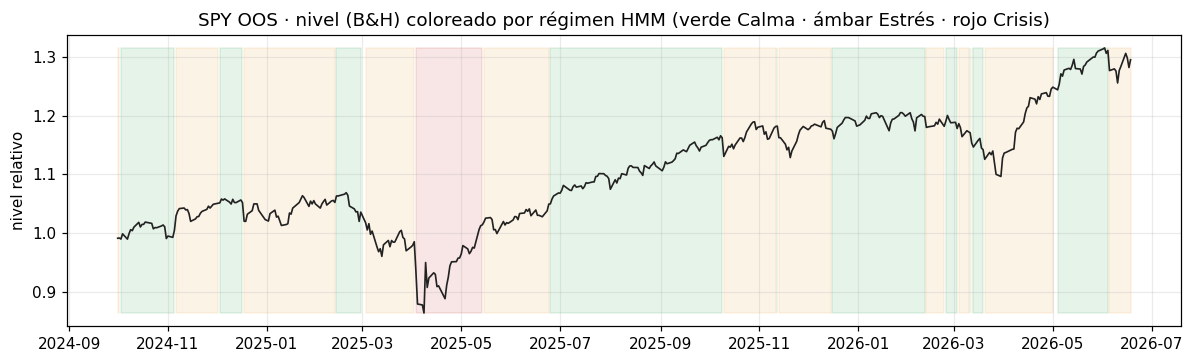

Calibración (2000–2024-09) · retorno medio del MISMO día por régimen:
   Calma  : ret_mismo_día=+0.000536  (n=2664)
   Estrés : ret_mismo_día=+0.000167  (n=2545)
   Crisis : ret_mismo_día=-0.000002  (n=995)
→ leverage effect: a mayor régimen de volatilidad, menor retorno el MISMO día (Calma > Estrés > Crisis).

Dirección del día SIGUIENTE por régimen (calibración) — proxy direccional sólo DÉBIL:
   Calma  : frac_sube_día_sig=0.5556  (≈0.5 ⇒ no informa el signo de r_(t+1))
   Estrés : frac_sube_día_sig=0.5391  (≈0.5 ⇒ no informa el signo de r_(t+1))
   Crisis : frac_sube_día_sig=0.5246  (≈0.5 ⇒ no informa el signo de r_(t+1))

OOS SPY · retorno medio del mismo día por régimen: {'Calma': '+0.00081', 'Estrés': '+0.00042', 'Crisis': '+0.00138'}
   (Crisis en OOS sale POSITIVO con n=29 muy pequeño; el HMM separa por VOLATILIDAD, no fija el
    signo del día siguiente. Mismo patrón que SMCI en §4.6: el valor direccional depende del leverage.)


In [3]:
# Régimen HMM en SPY (calibrado ex-ante) sobre el nivel B&H del OOS
from experiments.quant_validation_panel import build_states
gamma, sigma, oos_ret = build_states("SPY")
g = gamma.reindex(oos_ret.index).dropna()
dom = g.values.argmax(1)
px = (1 + oos_ret.reindex(g.index)).cumprod()
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(px.index, px.values, color="#222", lw=1.1)
for st in (0, 1, 2):
    ax.fill_between(px.index, float(px.min()), float(px.max()), where=(dom == st),
                    color=REGCOL[st], alpha=0.12, step="mid")
ax.set_title("SPY OOS · nivel (B&H) coloreado por régimen HMM (verde Calma · ámbar Estrés · rojo Crisis)")
ax.set_ylabel("nivel relativo"); plt.tight_layout(); plt.show()

# Leverage effect = relación CONTEMPORÁNEA (mismo día) entre régimen de vol y retorno.
# (1) Calibración 2000–2024-09 (regime_direction_table.json): el retorno del MISMO día baja al subir el régimen
cal = RDT["SPY"]["calib"]
print("Calibración (2000–2024-09) · retorno medio del MISMO día por régimen:")
for k in ("Calma", "Estrés", "Crisis"):
    print(f"   {k:7}: ret_mismo_día={cal[k]['ret_mismo_dia']:+.6f}  (n={cal[k]['n']})")
print("→ leverage effect: a mayor régimen de volatilidad, menor retorno el MISMO día (Calma > Estrés > Crisis).")
# (2) PERO el régimen NO predice la dirección del día SIGUIENTE: frac. que sube ≈ 0.5 incluso en Crisis
print("\nDirección del día SIGUIENTE por régimen (calibración) — proxy direccional sólo DÉBIL:")
for k in ("Calma", "Estrés", "Crisis"):
    print(f"   {k:7}: frac_sube_día_sig={cal[k]['frac_sube_sig']:.4f}  (≈0.5 ⇒ no informa el signo de r_(t+1))")
# (3) En el OOS el HMM separa por volatilidad (lo robusto); la media same-day en Crisis sale positiva (n pequeño)
rr = oos_ret.reindex(g.index)
means = {REGNAME[k]: float(rr[dom == k].mean()) for k in (0, 1, 2) if (dom == k).any()}
ncrisis = int((dom == 2).sum())
print("\nOOS SPY · retorno medio del mismo día por régimen:", {k: f"{v:+.5f}" for k, v in means.items()})
print(f"   (Crisis en OOS sale POSITIVO con n={ncrisis} muy pequeño; el HMM separa por VOLATILIDAD, no fija el")
print("    signo del día siguiente. Mismo patrón que SMCI en §4.6: el valor direccional depende del leverage.)")

## §4.3 Caso de estudio: SPY — el agente perdedor y su rescate

SPY es el escaparate del mecanismo. El agente (M5) acierta 0.37 y se arruina; la supervisión lo rescata. Y un
buscador automático de modelos (**AutoML-H2O**) llega a **ganar en punto a todas las estrategias** — un
resultado real que registramos con su matiz: es **nominal** frente al baseline trivial.

In [4]:
# Tabla SPY: las 6 estrategias (panel mm25 auditado)
tab = PAN["SPY"]["table"]
def fmt_row(s):
    t = tab[PKEY[s]]
    return {"acc": t["accuracy"], "AUC": t.get("auc"), "Sharpe": t["sharpe"],
            "maxDD": t["max_dd"], "Calmar": t["calmar"], "equity": t["equity_final"]}
spy = pd.DataFrame({s: fmt_row(s) for s in COL}).T
print("=== SPY · ventana desplegable (n =", PAN['SPY']['config']['n_test'], ") ===")
with pd.option_context("display.float_format", lambda v: f"{v:.4f}" if v is not None else "—"):
    print(spy)
zr = tab["zeror"]["accuracy"]; gan = max(COL, key=lambda s: tab[PKEY[s]]["accuracy"])
print(f"\nGanador en accuracy (NOMINAL): {gan} = {tab[PKEY[gan]]['accuracy']:.4f}  (ZeroR = {zr:.4f}, B&H = {tab['bh']['accuracy']:.4f})")
print("AutoML supera a TODAS en punto, también a ZeroR/B&H y en Sharpe/maxDD — pero ver McNemar abajo.")

=== SPY · ventana desplegable (n = 251 ) ===
          acc    AUC  Sharpe   maxDD  Calmar  equity
M5     0.3665    NaN -3.0700 -0.3025 -0.9990  0.6990
M8     0.4422    NaN -0.4640 -0.1520 -0.3900  0.9410
M10    0.4940 0.5309 -0.6040 -0.1609 -0.4980  0.9202
AutoML 0.5737 0.5521  2.6810 -0.0551  6.9290  1.3798
ZeroR  0.5657    NaN  2.2060 -0.0982  3.1020  1.3032
B&H    0.5657    NaN  2.2060 -0.0982  3.1020  1.3032

Ganador en accuracy (NOMINAL): AutoML = 0.5737  (ZeroR = 0.5657, B&H = 0.5657)
AutoML supera a TODAS en punto, también a ZeroR/B&H y en Sharpe/maxDD — pero ver McNemar abajo.


### ¿Es real ese "gana a todo"? Matriz McNemar (honesta)

McNemar pareado sobre los aciertos día a día. Dos lecturas opuestas y ambas ciertas:
- **Sí rescata al agente:** los modelos supervisados baten a **M5** de forma significativa.
- **No bate al baseline trivial:** ganar a **ZeroR/B&H** es **nominal** (p alto) — ventana corta, sin potencia.

In [5]:
# Matriz McNemar SPY (del panel): p-valores pareados
tests = PAN["SPY"]["tests"]
rows = []
for k, v in tests.items():
    if not isinstance(v, dict) or "p" not in v: continue
    a, b = k.replace("_xgb", "").split("_vs_")
    rows.append({"comparación": f"{a.upper()} vs {b.upper()}", "p_McNemar": round(v["p"], 4),
                 "sig_0.10": "SÍ" if v["p"] < 0.10 else "no"})
mc = pd.DataFrame(rows)
print(mc.to_string(index=False))
print("\nLectura honesta:")
print(" · vs M5 (agente): AutoML p≈%.4f, M10 p≈%.4f, M8 p≈%.4f  → RESCATE significativo del agente." % (
      tests["automl_vs_m5"]["p"], tests["m10_xgb_vs_m5"]["p"], tests["m8_vs_m5"]["p"]))
print(" · vs ZeroR: AutoML p≈%.3f, M10 p≈%.3f  → NOMINAL (no se bate al baseline trivial; ventana corta)." % (
      tests["automl_vs_zeror"]["p"], tests["m10_xgb_vs_zeror"]["p"]))

       comparación  p_McNemar sig_0.10
          M8 vs M5     0.0509       SÍ
         M10 vs M5     0.0074       SÍ
      AUTOML vs M5     0.0002       SÍ
       M5 vs ZEROR     0.0003       SÍ
       M8 vs ZEROR     0.0026       SÍ
      M10 vs ZEROR     0.1329       no
   AUTOML vs ZEROR     0.9020       no
      AUTOML vs M8     0.0059       SÍ
     AUTOML vs M10     0.0574       SÍ
    M5_SIGN vs 0.5     0.0000       SÍ
    M8_SIGN vs 0.5     0.0770       SÍ
   M10_SIGN vs 0.5     0.8996       no
AUTOML_SIGN vs 0.5     0.0229       SÍ
 ZEROR_SIGN vs 0.5     0.0432       SÍ
    BH_SIGN vs 0.5     0.0432       SÍ

Lectura honesta:
 · vs M5 (agente): AutoML p≈0.0002, M10 p≈0.0074, M8 p≈0.0509  → RESCATE significativo del agente.
 · vs ZeroR: AutoML p≈0.902, M10 p≈0.133  → NOMINAL (no se bate al baseline trivial; ventana corta).


### Rescate en riesgo, y por qué

Curvas de equity y diferencias de **riesgo** (Sharpe, maxDD) con **IC95 bootstrap** (Politis & Romano 1994). El
agente (M5) se hunde; M8/M10 controlan el riesgo. *A nivel SPY el IC todavía cruza 0* (poca potencia con n≈250);
la significancia del rescate de riesgo aparece en el **pooled** del panel (§4.4).

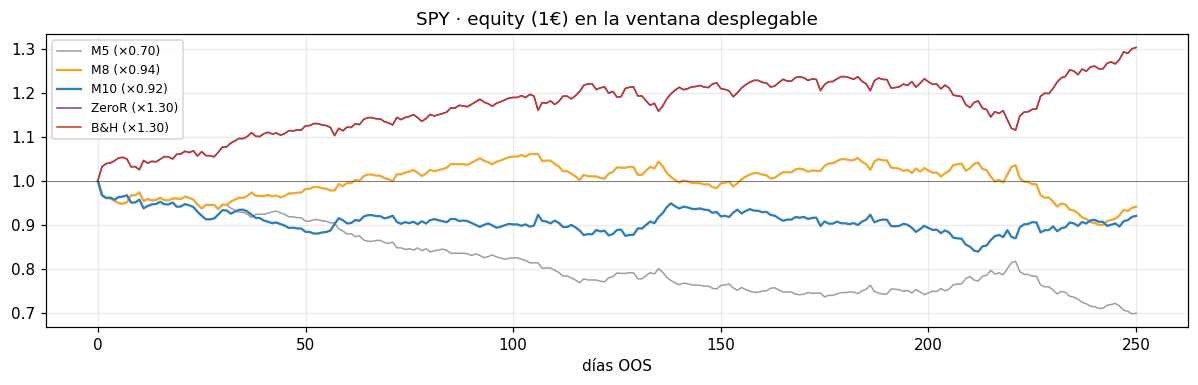

In [6]:
# Equity curves SPY (deterministas)
nr = DPA["SPY"]["net_returns"]
fig, ax = plt.subplots(figsize=(11, 3.6))
for s in ("M5", "M8", "M10", "ZeroR", "B&H"):
    eq = np.cumprod(1 + np.array(nr[DKEY[s]]))
    ax.plot(eq, color=COL[s], lw=1.5 if s in ("M8", "M10") else 1.0, label=f"{s} (×{eq[-1]:.2f})")
ax.axhline(1, color="k", lw=0.6, alpha=0.5)
ax.set_title("SPY · equity (1€) en la ventana desplegable"); ax.set_xlabel("días OOS"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [7]:
# Rescate del AGENTE (M5) y de B&H: ΔSharpe y ΔmaxDD con IC95 bootstrap
boot = DPA["SPY"]["boot"]
def show_boot(metric):
    print(f"--- SPY Δ{metric} (IC95 bootstrap; SIG = IC excluye 0) ---")
    for s in ("m8", "m10"):
        for b in ("m5", "bh", "zeror"):
            v = boot[f"{s}_vs_{b}"][metric]
            print(f"  {s.upper():4} vs {b.upper():5}: punto={v['point']:+.3f} IC{v['ci95']}  {'SIG' if v['sig'] else '—'}")
show_boot("dSharpe"); print(); show_boot("dMaxDD")
print("\nA nivel SPY el rescate de riesgo es DIRECCIONAL pero NO significativo (IC cruza 0, n≈250). "
      "La significancia llega en el pooled (§4.4). El signo 'punto' dice quién gana; 'SIG' solo que difieren.")

--- SPY ΔdSharpe (IC95 bootstrap; SIG = IC excluye 0) ---
  M8   vs M5   : punto=+2.606 IC[-0.242, 5.9353]  —
  M8   vs BH   : punto=-2.670 IC[-5.6822, 0.4859]  —
  M8   vs ZEROR: punto=-2.670 IC[-5.6822, 0.4859]  —
  M10  vs M5   : punto=+2.466 IC[-0.5479, 5.3382]  —
  M10  vs BH   : punto=-2.810 IC[-5.6, -0.2652]  SIG
  M10  vs ZEROR: punto=-2.810 IC[-5.6, -0.2652]  SIG

--- SPY ΔdMaxDD (IC95 bootstrap; SIG = IC excluye 0) ---
  M8   vs M5   : punto=+0.150 IC[-0.0174, 0.3051]  —
  M8   vs BH   : punto=-0.054 IC[-0.2298, 0.0351]  —
  M8   vs ZEROR: punto=-0.054 IC[-0.2298, 0.0351]  —
  M10  vs M5   : punto=+0.142 IC[-0.0458, 0.3427]  —
  M10  vs BH   : punto=-0.063 IC[-0.2056, 0.023]  —
  M10  vs ZEROR: punto=-0.063 IC[-0.2056, 0.023]  —

A nivel SPY el rescate de riesgo es DIRECCIONAL pero NO significativo (IC cruza 0, n≈250). La significancia llega en el pooled (§4.4). El signo 'punto' dice quién gana; 'SIG' solo que difieren.


Leader AutoML en SPY: GBM


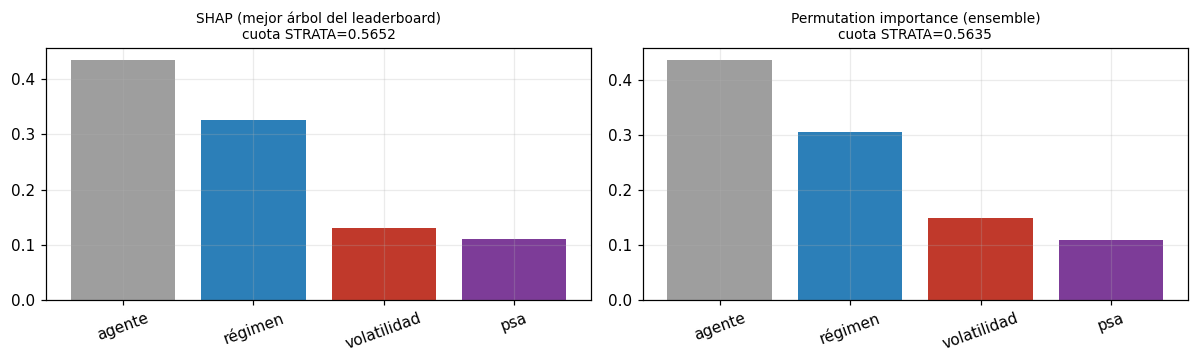

Un ENSEMBLE no admite atribución exacta por feature → SHAP del ÁRBOL (mejor del leaderboard); el ensemble se reporta con permutation importance. En SPY la cuota STRATA ≈ 0.57 (las STRATA pesan).


In [8]:
# ¿En qué se apoya el modelo en SPY? Importancia de features (AutoML), método correcto por modelo
imp = IMP.get("SPY", {})
print("Leader AutoML en SPY:", imp.get("leader_family", "?"))
sx = imp.get("shap_tree", {}); pe = imp.get("perm_importance_ensemble", {})
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, dat, ttl in [(axes[0], sx, "SHAP (mejor árbol del leaderboard)"),
                     (axes[1], pe, "Permutation importance (ensemble)")]:
    bl = dat.get("bloques")
    if bl:
        ks = list(bl); ax.bar(ks, [bl[k] for k in ks], color=["#9e9e9e", "#2c7fb8", "#c0392b", "#7d3c98"])
        ax.set_title(f"{ttl}\ncuota STRATA={dat.get('cuota_strata','?')}", fontsize=9)
        ax.tick_params(axis="x", rotation=20)
    else:
        ax.text(0.5, 0.5, dat.get("error", dat.get("warning", "n/d")), ha="center", va="center", fontsize=8)
        ax.set_title(ttl, fontsize=9)
plt.tight_layout(); plt.show()
print("Un ENSEMBLE no admite atribución exacta por feature → SHAP del ÁRBOL (mejor del leaderboard); el "
      "ensemble se reporta con permutation importance. En SPY la cuota STRATA ≈ %.2f (las STRATA pesan)." % (
      sx.get("cuota_strata", float('nan'))))

## §4.4 Generalización y universalidad (panel de 15 activos)

¿Es SPY un golpe de suerte o STRATA tiene efecto en todo el panel? Dos lecturas sobre el M10 canónico:
- **Ablación** — accuracy/Sharpe con solo las 15 features del agente vs las 22 (agente + STRATA).
- **SHAP por bloque** — de qué se fía el modelo. Si las **STRATA** dominan, el ML *redescubre* la señal de
  STRATA (hipótesis de universalidad §2.3 de la constitución): un meta-learner potente no la bate, la reencuentra.

In [9]:
# Ablación por activo + cuota STRATA en SHAP
rows = []
for a in ASSETS:
    abl = DPA[a]["ablation"]; sh = DPA[a]["shap"]
    rows.append({"activo": a, "acc_agente15": abl["acc"]["agente15"], "acc_all22": abl["acc"]["all22"],
                 "Δacc_STRATA": abl["d_acc_strata"], "cuota_STRATA_SHAP": sh["cuota_strata"]})
T = pd.DataFrame(rows).set_index("activo")
with pd.option_context("display.float_format", lambda v: f"{v:.3f}"):
    print(T)
print("\nMedias panel:  Δacc STRATA =", DP["medias"]["d_acc_strata"],
      "· cuota STRATA SHAP =", DP["medias"]["cuota_strata_shap"])
print("Honesto: añadir STRATA al vector de 15 del agente NO mueve la accuracy (Δ≈0, mixto) — el agente ya "
      "ocupa ese espacio. Pero el modelo SE APOYA en STRATA (cuota alta) y STRATA aporta sobre un baseline "
      "simple (ver §4.6, ablación SPY sobre momentum).")

        acc_agente15  acc_all22  Δacc_STRATA  cuota_STRATA_SHAP
activo                                                         
SPY            0.542      0.494       -0.048              0.715
QQQ            0.538      0.522       -0.016              0.688
DIA            0.464      0.468        0.004              0.644
IWM            0.478      0.458       -0.020              0.651
XLE            0.548      0.508       -0.040              0.581
XLF            0.502      0.526        0.024              0.624
XLK            0.606      0.542       -0.064              0.686
NVDA           0.521      0.483       -0.039              0.766
BAC            0.500      0.419       -0.081              0.582
TSLA           0.498      0.522        0.024              0.659
MSTR           0.458      0.534        0.076              0.680
SMCI           0.468      0.552        0.084              0.647
ROKU           0.508      0.508        0.000              0.604
MARA           0.472      0.532        0

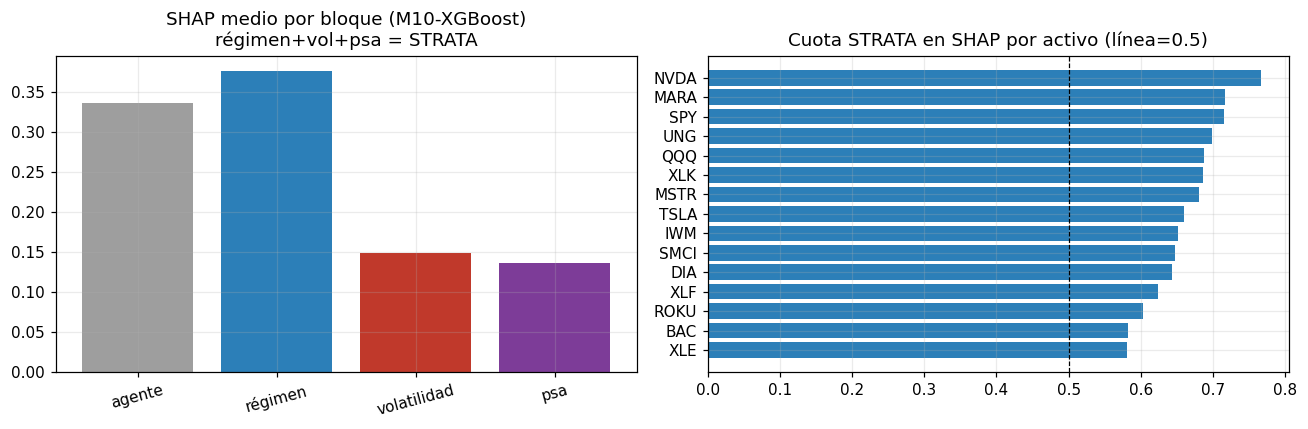

En 15/15 activos la cuota STRATA supera 0.5 → el ML se apoya más en STRATA que en el agente. Universalidad: el ML redescubre la señal de STRATA.


In [10]:
# SHAP medio por bloque (panel) + cuota STRATA por activo
bloN = list(DP["meta"]["bloques"])
blo_mean = {b: float(np.mean([DPA[a]["shap"]["bloques"][b] for a in ASSETS])) for b in bloN}
cuota = T["cuota_STRATA_SHAP"].sort_values()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.0))
axes[0].bar(bloN, [blo_mean[b] for b in bloN], color=["#9e9e9e", "#2c7fb8", "#c0392b", "#7d3c98"])
axes[0].set_title("SHAP medio por bloque (M10-XGBoost)\nrégimen+vol+psa = STRATA"); axes[0].tick_params(axis="x", rotation=15)
axes[1].barh(cuota.index, cuota.values, color="#2c7fb8")
axes[1].axvline(0.5, color="k", ls="--", lw=0.8); axes[1].set_title("Cuota STRATA en SHAP por activo (línea=0.5)")
plt.tight_layout(); plt.show()
print(f"En {int((cuota>0.5).sum())}/{len(cuota)} activos la cuota STRATA supera 0.5 → el ML se apoya más en "
      "STRATA que en el agente. Universalidad: el ML redescubre la señal de STRATA.")

        M5    M8   M10  AutoML  ZeroR   B&H
SPY  0.366 0.442 0.494   0.574  0.566 0.566
QQQ  0.418 0.486 0.522   0.534  0.590 0.590
DIA  0.440 0.484 0.468   0.520  0.552 0.556
IWM  0.450 0.470 0.458   0.482  0.554 0.574
XLE  0.448 0.528 0.508   0.532  0.565 0.565
XLF  0.429 0.502 0.526   0.510  0.538 0.538
XLK  0.510 0.470 0.542   0.590  0.641 0.641
NVDA 0.467 0.521 0.483   0.517  0.552 0.552
BAC  0.451 0.516 0.419   0.488  0.561 0.561
TSLA 0.474 0.478 0.522   0.454  0.458 0.530
MSTR 0.554 0.558 0.534   0.498  0.530 0.450
SMCI 0.484 0.496 0.552   0.472  0.516 0.484
ROKU 0.444 0.528 0.508   0.544  0.548 0.548
MARA 0.528 0.528 0.532   0.544  0.532 0.468
UNG  0.510 0.502 0.518   0.482  0.449 0.486


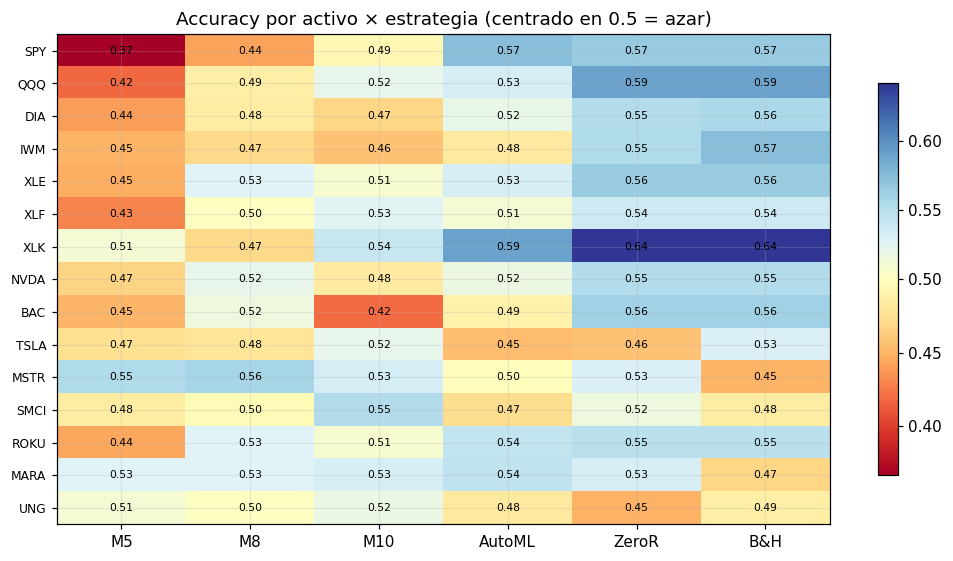

ZeroR gana en accuracy en la mayoría de activos (techo del baseline trivial). El valor de STRATA NO es batir ese techo en accuracy (§4.6) sino el rescate del agente y el control de riesgo.


In [11]:
# Tabla maestra panel (accuracy) + heatmap centrado en 0.5
acc = pd.DataFrame({s: {a: PAN[a]["table"][PKEY[s]]["accuracy"] for a in ASSETS} for s in COL}).loc[ASSETS]
with pd.option_context("display.float_format", lambda v: f"{v:.3f}"):
    print(acc)
M = acc[list(COL)].astype(float)
fig, ax = plt.subplots(figsize=(9.5, 5.2))
norm = TwoSlopeNorm(vmin=float(M.min().min()), vcenter=0.5, vmax=float(M.max().max()))
im = ax.imshow(M.values, cmap="RdYlBu", norm=norm, aspect="auto")
ax.set_xticks(range(len(COL))); ax.set_xticklabels(list(COL))
ax.set_yticks(range(len(ASSETS))); ax.set_yticklabels(ASSETS, fontsize=8)
for i in range(len(ASSETS)):
    for j, s in enumerate(COL):
        ax.text(j, i, f"{M.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Accuracy por activo × estrategia (centrado en 0.5 = azar)"); fig.colorbar(im, shrink=0.8)
plt.tight_layout(); plt.show()
print("ZeroR gana en accuracy en la mayoría de activos (techo del baseline trivial). El valor de STRATA NO "
      "es batir ese techo en accuracy (§4.6) sino el rescate del agente y el control de riesgo.")

=== POOLED (n=3751 días, 15 activos) ===
 comparación  ΔSharpe        Sharpe_IC95 Sharpe_sig  ΔmaxDD        maxDD_IC95 maxDD_sig
    m8_vs_m5   0.6641    [0.2252, 1.157]        SIG  0.2424  [0.0171, 0.4447]       SIG
    m8_vs_bh   0.0144  [-0.8193, 0.8726]          —  0.1556  [-0.296, 0.3595]         —
 m8_vs_zeror  -0.4127 [-0.8638, -0.0319]        SIG  0.0104 [-0.3491, 0.0737]         —
   m10_vs_m5   0.6077  [-0.0372, 1.2453]          —  0.2301  [-0.016, 0.4545]         —
   m10_vs_bh  -0.0420  [-0.7901, 0.6572]          —  0.1433 [-0.2945, 0.3466]         —
m10_vs_zeror  -0.4691  [-1.1774, 0.1434]          — -0.0019 [-0.4283, 0.2072]         —


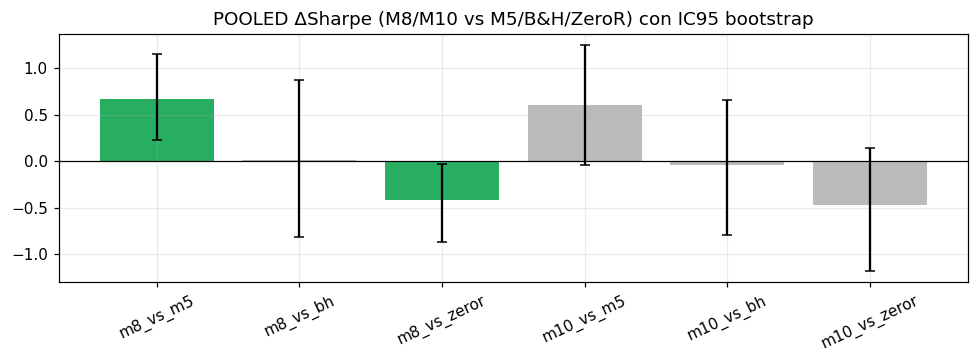


Resultado clave: M8 rescata al agente en riesgo de forma SIGNIFICATIVA en el pooled — ΔSharpe +0.66 IC[0.2252, 1.157], ΔmaxDD +0.24 IC[0.0171, 0.4447] (ambos excluyen 0). Esta es la pata dura del valor de STRATA.


In [12]:
# Significancia de RIESGO (lo robusto): bootstrap POOLED de ΔSharpe y ΔmaxDD
pb = DP["pooled"]["boot"]
print(f"=== POOLED (n={DP['pooled']['n_total']} días, {DP['pooled']['n_activos']} activos) ===")
rows = []
for key, v in pb.items():
    rows.append({"comparación": key, "ΔSharpe": v["dSharpe"]["point"], "Sharpe_IC95": str(v["dSharpe"]["ci95"]),
                 "Sharpe_sig": "SIG" if v["dSharpe"]["sig"] else "—",
                 "ΔmaxDD": v["dMaxDD"]["point"], "maxDD_IC95": str(v["dMaxDD"]["ci95"]),
                 "maxDD_sig": "SIG" if v["dMaxDD"]["sig"] else "—"})
print(pd.DataFrame(rows).to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 3.4))
labels = list(pb); pts = [pb[k]["dSharpe"]["point"] for k in labels]
err = [[pb[k]["dSharpe"]["point"] - pb[k]["dSharpe"]["ci95"][0] for k in labels],
       [pb[k]["dSharpe"]["ci95"][1] - pb[k]["dSharpe"]["point"] for k in labels]]
cols = ["#27ae60" if pb[k]["dSharpe"]["sig"] else "#bbb" for k in labels]
ax.bar(labels, pts, yerr=err, color=cols, capsize=3); ax.axhline(0, color="k", lw=0.8)
ax.set_title("POOLED ΔSharpe (M8/M10 vs M5/B&H/ZeroR) con IC95 bootstrap"); ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()
v = pb["m8_vs_m5"]
print(f"\nResultado clave: M8 rescata al agente en riesgo de forma SIGNIFICATIVA en el pooled — "
      f"ΔSharpe {v['dSharpe']['point']:+.2f} IC{v['dSharpe']['ci95']}, ΔmaxDD {v['dMaxDD']['point']:+.2f} "
      f"IC{v['dMaxDD']['ci95']} (ambos excluyen 0). Esta es la pata dura del valor de STRATA.")

## §4.5 Patrón entre activos: ¿qué estrategia conviene a cada tipo de activo?

No todos los activos son iguales: cambian el leverage effect, la volatilidad y el sesgo del agente. Agrupando
por **naturaleza** (no por rendimiento, para no hacer trampa), ¿emerge qué estrategia conviene a cada grupo?
Probamos varios algoritmos adecuados a $n=15$ pequeño y features continuas: **KMeans, Ward, GaussianMixture
(+BIC), Spectral**. La elección final del algoritmo la decide Raquel; aquí se muestra cuánto coinciden.

In [13]:
# Comparación de algoritmos: silhouette + BIC + concordancia
clus = CLU["clustering"]
sil = pd.DataFrame({k: {mth: clus[k][mth].get("silhouette") for mth in ("kmeans", "ward", "gmm", "spectral")}
                    for k in ("k2", "k3", "k4")})
print("=== Silhouette (mayor = mejor separación) ==="); print(sil)
print("\nGMM BIC (menor = mejor):", {k: clus[k]["gmm"].get("bic") for k in ("k2", "k3", "k4")})
print("Concordancia a k=3 (Rand ajustado, 1=idénticos):", CLU["concordancia_k3_randajustado"])
print("→ KMeans, Ward y GMM coinciden (Rand=1.0); Spectral difiere. Consenso fuerte en k=3.")

=== Silhouette (mayor = mejor separación) ===
              k2      k3      k4
kmeans    0.4587  0.4852  0.4560
ward      0.4587  0.4852  0.4560
gmm       0.3601  0.4852  0.4560
spectral  0.4587  0.1797  0.2099

GMM BIC (menor = mejor): {'k2': 122.13, 'k3': 14.67, 'k4': -27.78}
Concordancia a k=3 (Rand ajustado, 1=idénticos): {'kmeans~ward': 1.0, 'kmeans~gmm': 1.0, 'kmeans~spectral': 0.401, 'ward~gmm': 1.0, 'ward~spectral': 0.401, 'gmm~spectral': 0.401}
→ KMeans, Ward y GMM coinciden (Rand=1.0); Spectral difiere. Consenso fuerte en k=3.


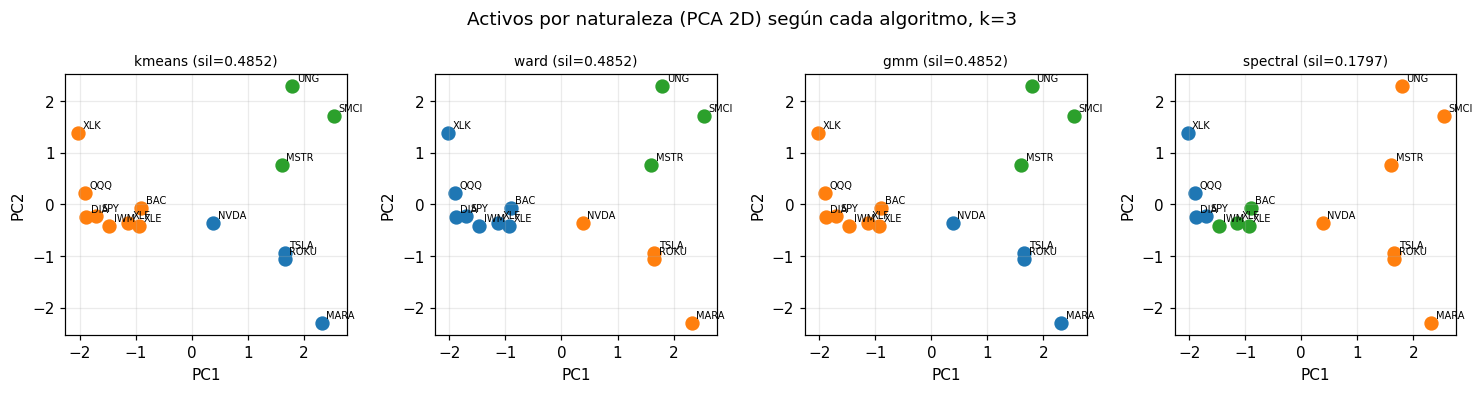

In [14]:
# PCA 2D de la naturaleza, coloreado por método (k=3)
from sklearn.decomposition import PCA
Xs = np.array(CLU["meta"]["X_estandarizada"]); ok = CLU["meta"]["panel"]
pca = PCA(n_components=2).fit_transform(Xs)
mets = [m for m in ("kmeans", "ward", "gmm", "spectral") if "labels" in clus["k3"][m]]
fig, axes = plt.subplots(1, len(mets), figsize=(3.4 * len(mets), 3.6), squeeze=False)
for ax, mth in zip(axes[0], mets):
    lab = np.array(clus["k3"][mth]["labels"])
    for c in sorted(set(lab)):
        ax.scatter(pca[lab == c, 0], pca[lab == c, 1], s=70, label=f"C{c}")
    for i, t in enumerate(ok):
        ax.annotate(t, (pca[i, 0], pca[i, 1]), fontsize=6.5, xytext=(3, 3), textcoords="offset points")
    ax.set_title(f"{mth} (sil={clus['k3'][mth]['silhouette']})", fontsize=9)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
fig.suptitle("Activos por naturaleza (PCA 2D) según cada algoritmo, k=3"); plt.tight_layout(); plt.show()

In [15]:
# Perfiles de grupo (KMeans k=3): naturaleza media + mejor estrategia
prof = CLU["perfiles_k3"].get("kmeans", {})
for c, d in prof.items():
    nat = d["naturaleza_media"]
    print(f"\n{c}: {d['activos']}")
    print(f"   naturaleza: leverage={nat['leverage_corr']:+.3f} crisis_mean={nat['crisis_mean']:+.5f} "
          f"vol={nat['oos_vol']:.2f} agente_corto={nat['agent_short_frac']:.2f}")
    print(f"   acc media: " + " ".join(f"{s}={d['acc_media'][s]:.3f}" for s in ("M5","M8","M10","Régimen","AutoML","ZeroR")))
    print(f"   → mejor no-trivial: accuracy={d['mejor_acc_no_trivial']} · Sharpe={d['mejor_sharpe_no_trivial']}")
print("\nPatrón (HIPÓTESIS, n=15 exploratorio): índices de leverage fuerte → régimen/M8; volátiles → "
      "AutoML/M10; cripto-proxy/inverso → M10/M8. Qué algoritmo fijar = decisión de Raquel.")


C0: ['NVDA', 'TSLA', 'ROKU', 'MARA']
   naturaleza: leverage=-0.019 crisis_mean=+0.00360 vol=0.65 agente_corto=0.93
   acc media: M5=0.478 M8=0.514 M10=0.511 Régimen=0.509 AutoML=0.515 ZeroR=0.541
   → mejor no-trivial: accuracy=AutoML · Sharpe=M10

C1: ['SPY', 'QQQ', 'DIA', 'IWM', 'XLE', 'XLF', 'XLK', 'BAC']
   naturaleza: leverage=-0.093 crisis_mean=-0.00040 vol=0.18 agente_corto=0.68
   acc media: M5=0.439 M8=0.487 M10=0.492 Régimen=0.548 AutoML=0.529 ZeroR=0.574
   → mejor no-trivial: accuracy=Régimen · Sharpe=Régimen

C2: ['MSTR', 'SMCI', 'UNG']
   naturaleza: leverage=+0.018 crisis_mean=-0.00050 vol=0.69 agente_corto=0.98
   acc media: M5=0.516 M8=0.519 M10=0.535 Régimen=0.483 AutoML=0.484 ZeroR=0.527
   → mejor no-trivial: accuracy=M10 · Sharpe=M8

Patrón (HIPÓTESIS, n=15 exploratorio): índices de leverage fuerte → régimen/M8; volátiles → AutoML/M10; cripto-proxy/inverso → M10/M8. Qué algoritmo fijar = decisión de Raquel.


## §4.6 Robustez y honestidad

Tres bloques: (a) ¿la señal de STRATA es robusta más allá del meta-learner?; (b) ¿dónde NO funciona? (caso
SMCI, leverage débil), con su suite de robustez pre-registrada; (c) meta-análisis honesto de qué es nominal y
qué sobrevive a un test.

In [16]:
# (a) SPY: ¿STRATA aporta sobre un baseline de momentum? (ablación por bloques de semillas)
r = SPYA["resumen"]
print("=== SPY · ablación STRATA sobre momentum (%d bloques de semillas) ===" % r["n_bloques"])
print(f" momentum solo:   acc {r['acc_momentum_solo']['media']:.4f}")
print(f" STRATA7 + mom:   acc {r['acc_strata7+mom']['media']:.4f}  (Sharpe {r['sharpe_strata7+mom']['media']:.2f})")
c1 = r["C1_strata_sobre_mom"]
print(f" Δacc por STRATA: {c1['delta_acc_media']:+.4f} (min {c1['delta_acc_min']:+.4f}); "
      f"{c1['bloques_delta_positivo']}/{r['n_bloques']} bloques positivos, "
      f"{c1['bloques_mcnemar_sig_0.10']}/{r['n_bloques']} McNemar sig. a 0.10")
print("→ Sobre un baseline simple, STRATA SÍ añade señal (consistente con la cuota SHAP alta del §4.4).")

=== SPY · ablación STRATA sobre momentum (5 bloques de semillas) ===
 momentum solo:   acc 0.5211
 STRATA7 + mom:   acc 0.5817  (Sharpe 2.85)
 Δacc por STRATA: +0.0606 (min +0.0518); 5/5 bloques positivos, 3/5 McNemar sig. a 0.10
→ Sobre un baseline simple, STRATA SÍ añade señal (consistente con la cuota SHAP alta del §4.4).


In [17]:
# (b) SMCI: el límite honesto (leverage débil → poco margen de rescate). Suite pre-registrada.
p = SMV["principal_todo_oos"]
print("=== SMCI · M10 desplegable (n=%d) — caso de LIMITACIÓN ===" % p["n"])
print(f" acc: M5={p['m5']['acc']:.3f}  M8={p['m8']['acc']:.3f}  M10={p['m10']['acc']:.3f}  "
      f"B&H={p['bh']['acc']:.3f}  mayoría={p['majority']['acc']:.3f}")
print(f" M10 gana a todo (nominal): {SMV['m10_gana_a_todo_en_todos']}  · binomial M10 vs NIR p={p['binom_m10_vs_nir_p']:.3f} (no sig)")
print(f" embargo: {SME['meta']['lectura']}")
print(f" ventanas rodantes (M10>B&H): " + " ".join(f"{w}d={SMR['frac_ventanas_m10_gana'][w]['m10_gt_bh']:.0%}" for w in ("42","63","84")))
print(f" block-perm vs B&H p={SMR['significancia_global']['block_perm_vs_bh_p']:.3f} "
      f"(no sobrevive Bonferroni-5≈{SME['meta']['bonferroni5_min_blockperm_vs_bh']})")
# régimen Crisis en SMCI: media positiva → el régimen separa por VOL pero no es direccional (leverage débil)
vw = SMC["por_ventana"][0]["medias_regimen"]
print(f" régimen SMCI (media same-day): Calma={vw['Calma']:+.5f} Estrés={vw['Estrés']:+.5f} Crisis={vw['Crisis']:+.5f}")
print(" → mismo criterio que en SPY (§4.2): el HMM separa por VOLATILIDAD pero el signo no es fiable; aquí ni")
print("   siquiera same-day baja con el régimen, así que como proxy DIRECCIONAL no sirve (leverage débil) y")
print("   STRATA rescata poco. Coherente con que en SPY el día-siguiente tampoco es direccional (frac≈0.52).")

=== SMCI · M10 desplegable (n=250) — caso de LIMITACIÓN ===
 acc: M5=0.484  M8=0.496  M10=0.552  B&H=0.484  mayoría=0.516
 M10 gana a todo (nominal): True  · binomial M10 vs NIR p=0.141 (no sig)
 embargo: pico aislado de sig. en emb=1 (emb 0 y 2 no sig) → ruido; emb=1 por principio, no por p
 ventanas rodantes (M10>B&H): 42d=71% 63d=74% 84d=82%
 block-perm vs B&H p=0.047 (no sobrevive Bonferroni-5≈0.2832)
 régimen SMCI (media same-day): Calma=-0.00001 Estrés=+0.00163 Crisis=+0.00160
 → mismo criterio que en SPY (§4.2): el HMM separa por VOLATILIDAD pero el signo no es fiable; aquí ni
   siquiera same-day baja con el régimen, así que como proxy DIRECCIONAL no sirve (leverage débil) y
   STRATA rescata poco. Coherente con que en SPY el día-siguiente tampoco es direccional (frac≈0.52).


In [18]:
# (c) Meta-análisis de significancia: qué es NOMINAL y qué sobrevive a un test
print("=== ¿Qué sobrevive a un test? (resumen honesto) ===")
filas = [
  ("Rescate del agente (accuracy)", "McNemar M10/AutoML vs M5 (SPY)",
   f"p={PAN['SPY']['tests']['m10_xgb_vs_m5']['p']:.4f} / {PAN['SPY']['tests']['automl_vs_m5']['p']:.4f}", "SÍ sig."),
  ("Rescate del agente (riesgo)", "bootstrap ΔSharpe/ΔmaxDD M8 vs M5 (POOLED)",
   f"IC{DP['pooled']['boot']['m8_vs_m5']['dSharpe']['ci95']}", "SÍ sig."),
  ("Universalidad (el ML usa STRATA)", "cuota SHAP STRATA (panel)",
   f"media {DP['medias']['cuota_strata_shap']:.2f}", "SÍ (descriptivo)"),
  ("Batir a ZeroR/B&H (accuracy)", "McNemar AutoML vs ZeroR (SPY)",
   f"p={PAN['SPY']['tests']['automl_vs_zeror']['p']:.3f}", "NO (nominal)"),
  ("SMCI bate a todo (accuracy)", "binomial M10 vs NIR / block-perm Bonferroni",
   f"p={SMV['principal_todo_oos']['binom_m10_vs_nir_p']:.3f}", "NO (nominal)"),
]
print(pd.DataFrame(filas, columns=["afirmación", "test", "evidencia", "veredicto"]).to_string(index=False))
print("\nConclusión metodológica: el valor de STRATA NO es batir al mercado/baseline en accuracy (eso es "
      "nominal, ventana corta → futuro). Es el RESCATE del agente (sig. en accuracy y en riesgo pooled) y la "
      "UNIVERSALIDAD (el ML redescubre STRATA). La regla prior-flip pre-registra cuándo NO funciona.")

=== ¿Qué sobrevive a un test? (resumen honesto) ===
                      afirmación                                        test         evidencia        veredicto
   Rescate del agente (accuracy)              McNemar M10/AutoML vs M5 (SPY) p=0.0074 / 0.0002          SÍ sig.
     Rescate del agente (riesgo)  bootstrap ΔSharpe/ΔmaxDD M8 vs M5 (POOLED) IC[0.2252, 1.157]          SÍ sig.
Universalidad (el ML usa STRATA)                   cuota SHAP STRATA (panel)        media 0.66 SÍ (descriptivo)
    Batir a ZeroR/B&H (accuracy)               McNemar AutoML vs ZeroR (SPY)           p=0.902     NO (nominal)
     SMCI bate a todo (accuracy) binomial M10 vs NIR / block-perm Bonferroni           p=0.141     NO (nominal)

Conclusión metodológica: el valor de STRATA NO es batir al mercado/baseline en accuracy (eso es nominal, ventana corta → futuro). Es el RESCATE del agente (sig. en accuracy y en riesgo pooled) y la UNIVERSALIDAD (el ML redescubre STRATA). La regla prior-flip pre-registra cuá

## §4.7 Conclusiones del marco práctico

Cada conclusión, con su validación:

1. **El agente solo pierde y acierta < 0.5 (O1).** SPY: M5 acc 0.37, Sharpe muy negativo; sign test rechaza 0.5.
2. **STRATA rescata al agente — y se prueba (O2).** Accuracy: McNemar M10/AutoML vs M5 significativo (SPY
   p≈0.007 / p≈0.0002). Riesgo: bootstrap pooled M8 vs M5 ΔSharpe +0.66 IC[0.23,1.16] y ΔmaxDD +0.24
   IC[0.02,0.44], ambos excluyen 0. **Esta es la aportación dura.**
3. **Universalidad: el ML redescubre STRATA (O3).** Cuota STRATA en SHAP media ≈ 0.66 (dos métodos, árbol +
   permutation); sobre un baseline de momentum STRATA añade +0.06 de accuracy en SPY. Añadirla al vector del
   agente no sube la accuracy (Δ≈0): el efecto es rescate + interpretabilidad, no más accuracy del meta-learner.
4. **Hay patrón activo→estrategia (O4).** Clustering por naturaleza con consenso fuerte (KMeans/Ward/GMM
   coinciden, Rand=1.0, k=3): índices de leverage fuerte → régimen/M8; volátiles → AutoML/M10; cripto/inverso →
   M10/M8. Exploratorio (n=15).
5. **Honestidad y límite (O5).** No se bate a ZeroR/B&H en accuracy de forma significativa (McNemar vs ZeroR
   p≈0.90 en SPY; SMCI nominal): ventana corta → línea futura. STRATA no genera alfa. El HMM separa por
   volatilidad en todos los activos, pero su utilidad **direccional** depende del leverage: donde es débil
   (SMCI) el régimen no fija el signo y el rescate es escaso — límite pre-registrado (decisión #16).
6. **Todo con rigor (O6).** `signal_lag=1`, embargo=1, modelos ex-ante, bootstrap/McNemar/sign con cita,
   pre-registro en BITÁCORA, auto-test que cruza cada headline con su JSON.

**Tesis sostenida:** supervisar estadísticamente a un agente LLM **aporta valor diferencial medible** — rescate
significativo del agente (accuracy y riesgo) y una mecánica interpretable que un ML potente redescubre. Lo que
queda fuera (batir al mercado / significancia de accuracy) se reporta honestamente como límite y trabajo futuro.

In [19]:
# --- AUTO-TEST: los headlines del cuaderno cuadran con los JSON auditados ---
# §4.3 SPY: AutoML gana en punto a todas (nominal)
tab = PAN["SPY"]["table"]
assert max(("m5","m8","m10_xgb","automl","zeror","bh"), key=lambda k: tab[k]["accuracy"]) == "automl", "AutoML no es el máx en SPY"
assert PAN["SPY"]["tests"]["automl_vs_zeror"]["p"] > 0.5, "AutoML vs ZeroR debería ser NOMINAL"
assert PAN["SPY"]["tests"]["m10_xgb_vs_m5"]["p"] < 0.10, "M10 vs M5 (rescate) debería ser sig."
# §4.4 universalidad + pooled riesgo
assert len(ASSETS) == 15, "faltan activos en el panel"
assert DP["medias"]["cuota_strata_shap"] > 0.5, "cuota STRATA media debería superar 0.5"
pm = DP["pooled"]["boot"]["m8_vs_m5"]
assert pm["dSharpe"]["sig"] and pm["dMaxDD"]["sig"], "rescate de riesgo M8 vs M5 debería ser SIG en pooled"
# §4.5 clustering consenso
assert CLU["concordancia_k3_randajustado"]["kmeans~ward"] == 1.0, "KMeans y Ward deberían coincidir"
# §4.6 SMCI nominal + leverage débil
assert SMV["principal_todo_oos"]["binom_m10_vs_nir_p"] > 0.10, "SMCI debería ser NOMINAL"
assert SMC["por_ventana"][0]["medias_regimen"]["Crisis"] > 0, "SMCI Crisis debería tener media positiva (leverage débil)"
print("AUTO-TEST OK · headlines coherentes con panel mm25 / prep / clustering15 / SPY+SMCI suites")
print("§4.3 AutoML gana nominal · §4.2/4.3 rescate del agente sig · §4.4 universalidad+riesgo pooled sig · "
      "§4.5 consenso clustering · §4.6 SMCI nominal/leverage débil")

AUTO-TEST OK · headlines coherentes con panel mm25 / prep / clustering15 / SPY+SMCI suites
§4.3 AutoML gana nominal · §4.2/4.3 rescate del agente sig · §4.4 universalidad+riesgo pooled sig · §4.5 consenso clustering · §4.6 SMCI nominal/leverage débil
